# Data Processing

In this part, we process our features to ensure consistency in their detection and comparability between samples. Qualitative features should follow at least these criteria:
- Limited Variability across samples of the same class (<30% on the QC)
- Consistent support in detection (>=70% on the same class)
- Within mass range of interest (glycans > 500 m/z)
- Monitor sample-to-sample intensity variations and check for possible transformations that could improve comparability
- Basically monitor defaults that are due to instrument accuracy and experimental conditions and correct them
- Output: list of efatures and samples we will leverage for doing biomarker discovery.
- Justifications for selection or removal of others.

In [1]:
# Imports

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Personal Functions
from helpers import *

# Machine Learning Functions
from scipy.interpolate import UnivariateSpline

In [2]:
# Load datasets: Data Matrix, Feature Metadata, Acquisition List, and Exogenous Standards
data_matrix = pd.read_csv("./data/input/internship_data_matrix.csv")
feature_metadata = pd.read_csv("./data/input/internship_feature_metadata.csv")
acquisition_list = pd.read_csv("./data/input/intership_acquisition_list.csv")
exogenous_stds = pd.read_csv("./data/input/exogenous_standards.csv")

# Set index columns to ensure consistent sample/feature alignment across datasets
data_matrix = data_matrix.set_index('sample')              
feature_metadata = feature_metadata.set_index('feature')  
acquisition_list = acquisition_list.set_index('sample')    
exogenous_stds = exogenous_stds.set_index('compound_id')  

# Print shape of data frames
print(f"Shape of Data Matrix: {data_matrix.shape}")
print(f"Shape of Feature Metadata: {feature_metadata.shape}")
print(f"Shape of Acquisition List: {acquisition_list.shape}")
print(f"Shape of Exogenus Standards: {exogenous_stds.shape}")

# Merge Acquisition List with Data Matrix to include sample metadata (class, batch, run order)
data_matrix_types = data_matrix.join(other=acquisition_list)
print(f"Shape of Data Matrix with sample metadata: {data_matrix_types.shape}")

# Consider 'dQC' as 'QC' since diltued quality checks can be considered as normal quality checks
data_matrix_types['class'] = data_matrix_types['class'].replace('dQC', 'QC')

# Only keep batch 1
data_matrix = data_matrix[data_matrix_types['batch'] == 1]
data_matrix_types = data_matrix_types[data_matrix_types['batch'] == 1]
print(data_matrix_types['batch'].unique(), len(data_matrix_types), len(data_matrix)) #verification

print(f"Shape of Data Matrix with only batch 1 measurements: {data_matrix.shape}")
print(f"Shape of Data Matrix with sample metadata with only batch 1 measurements: {data_matrix_types.shape}")

# Print initial number of features to keep track of how many features we get rid of
print(f"Initial number of features: {data_matrix.shape[1]}")

Shape of Data Matrix: (124, 252)
Shape of Feature Metadata: (252, 10)
Shape of Acquisition List: (124, 4)
Shape of Exogenus Standards: (4, 2)
Shape of Data Matrix with sample metadata: (124, 256)
[1] 102 102
Shape of Data Matrix with only batch 1 measurements: (102, 252)
Shape of Data Matrix with sample metadata with only batch 1 measurements: (102, 256)
Initial number of features: 252


## Feature Selection: limited variability across samples of the same class

In this part, we will restrain our data to only keep samples of the same class that have < 30% variability on the QC.

In [3]:
# Define data matrix with only QC samples
qc = data_matrix.loc[data_matrix_types[data_matrix_types['class'] == 'QC'].index]

# Compute Coefficient of Variation (CV) of features across QC samples
cv_qc = compute_class_cv(data_matrix, data_matrix_types, 'QC', 1)

# Keep only features for which CV < 30%
filtered_data_matrix = data_matrix[cv_qc[cv_qc < 30].index]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

Number of features left: 159


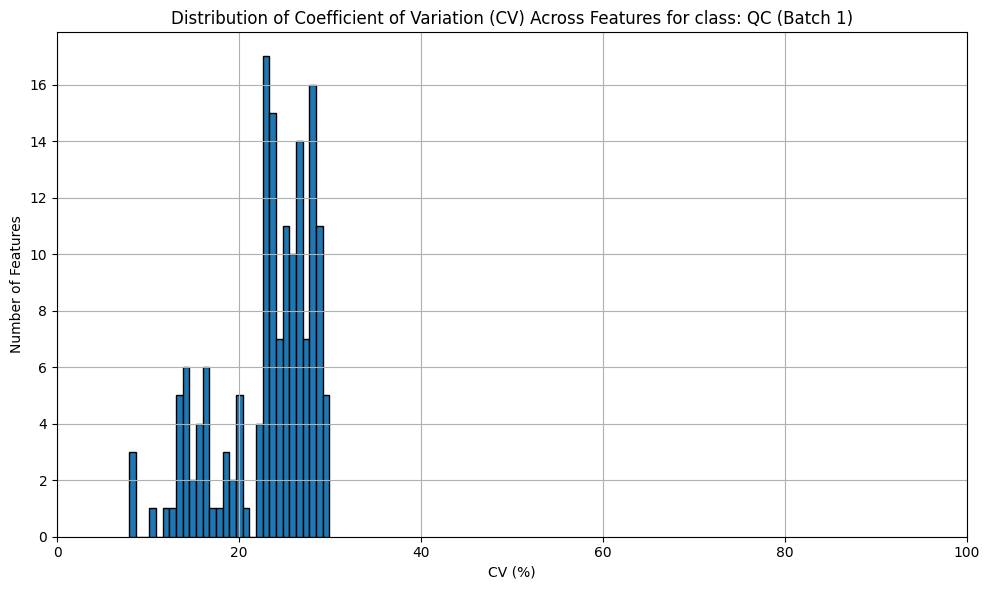

In [4]:
# Verification: Compute and Plot CV of features across QC samples after filtering
cv_qc = compute_class_cv(filtered_data_matrix, data_matrix_types, 'QC', 1, visualize=True, xlim=[0, 100])

The distribution of CV across features for QC samples after filtering confirms that we only keep features for which the CV is lower than 30%.

## Feature Selection: consistent support in detection

Next, we will restrain our data to only keep features that are consistenly detected, i.e. the features that are detected more than 70% of the time across samples of the same class.
From the Exploratory Data Analysis, we have explored three ways to define a threshold for detection. Here, we will choose to work with the manual threshold.

In [5]:
threshold = 10 # manual threshold for peak area value to consider feature as detected
detected = 70 # only keep features that are detected >70% of the time

# Loop over classes of samples
classes = data_matrix_types['class']
reliable_features = []
for c in classes:
    # Only keep data of samples from specific class
    filtered_data_matrix_types = filtered_data_matrix.join(other=acquisition_list)
    class_data = filtered_data_matrix[filtered_data_matrix_types['class'] == c]
    
    # Keep only features detected in >=70% of samples
    detection_rate = (class_data > threshold).sum(axis=0)/len(class_data)*100 # compute percentage of samples where value > threshold
    
    for feature in detection_rate[detection_rate >= detected].index:
        if feature in reliable_features:
            break # don't add feature if it was already added before
        else:
            reliable_features.append(feature) # add feature to the reliable features

filtered_data_matrix = filtered_data_matrix[reliable_features]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

Number of features left: 159


## Feature Selection: within mass range of interest

In this part, we will only keep features that correspond to glycans, i.e. features for which mass-to-charge ratio (m/z) > 500.

Number of features left: 156


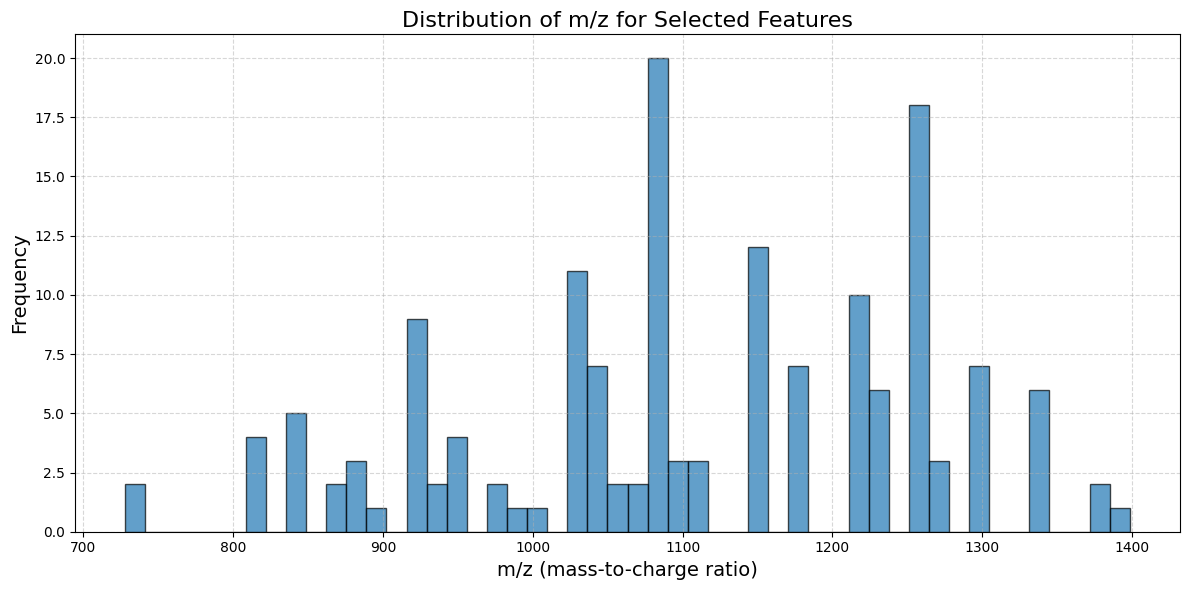

In [6]:
# Identify features of m/z > 500
filtered_feature_metadata = feature_metadata.loc[filtered_data_matrix.columns]
glycan_features = filtered_feature_metadata[filtered_feature_metadata['mz'] > 500].index

# Filter data matrix to only keep features of m/z > 500
filtered_data_matrix = filtered_data_matrix[glycan_features]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

# Verification: plot the distribution of m/z of features of filtered data matrix
selected_features = feature_metadata.loc[filtered_data_matrix.columns] # filter feature metadata as to only keep selected features
plt.figure(figsize=(12, 6))
plt.hist(selected_features['mz'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of m/z for Selected Features', fontsize=16)
plt.xlabel('m/z (mass-to-charge ratio)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The distribution of m/z for selected features confirms that we only keep the features for which m/z is higher than 500, which corresponds to glycans.

## Feature Selection: D-ratio

We remind the definition of the d-ratio:

The D-ratio represents the relation of the statistical dispersion of the QCs to the dispersion of the biological test samples. The D-ratio is calculated by dividing the technical variation by the total observed variation; this is the sum of technical and biological variation. Here, the variance of the QCs (𝜎2𝑖,𝑄⁢𝐶) approximates the technical variation, and the variance of the biological test samples (𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒) approximates the overall biological variation.

<img src="./images/D_ratio.png" alt="Alt Text" width="300"/>

A D-ratio close to 0% would be a perfect measurement, where the technical variance is zero and all observed variance originates from the biological variation. On the other hand, a D-ratio of 100% would be the worst possible measurement, where there is no biological variation and only noise is detected. A metabolite, where 𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒 ≫ 𝜎2𝑖,𝑄⁢𝐶 with a D-ratio below 50%, is preferred.

This information was provided in the paper [Instrumental Drift in Untargeted Metabolomics: Optimizing Data Correction Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/).

In this section, we will check whether the d-ratio of our filtered data matrix is acceptable. If not, we will explore normalization methods to decrease the d-ratio.

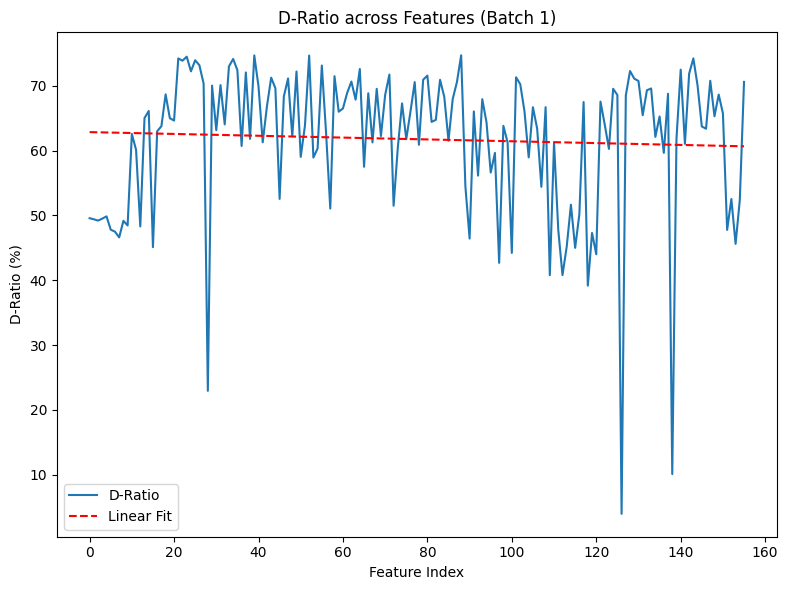

FT-002    49.567039
FT-004    49.402388
FT-005    49.201976
FT-006    49.505029
FT-007    49.859991
            ...    
FT-238    47.764080
FT-240    52.532731
FT-242    45.618667
FT-244    52.383162
FT-248    70.596932
Length: 156, dtype: float64

In [7]:
# Compute the d-ratio of filtered data matrix
compute_d_ratio(filtered_data_matrix, data_matrix_types, 1)

- The linear fit across all features shows a slight decreasing trend. This indicates no major drift in D-Ratio across the feature index.
- D-Ratio values mostly range between 45–75%, with a few features dropping below 30% or even below 10%.

According to the paper [Instrumental Drift in Untargeted Metabolomics: Optimizing Data Correction Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/), D-Ratio values under 50% suggest stronger biological signal, i.e., the feature varies more between classes than within QC samples. In order to achieve lower d-ratio values, we investigate normalization methods suggested in the paper to improve comparability between samples. We then re-check d-ratios to see if they decrease.

### Normalization method: Median Normalization

​Based on the normalization methods proposed in the paper [Instrumental Drift in Untargeted Metabolomics: Optimizing Data Correction Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/), we can implement the following approaches to correct for batch effects and instrumental drift in our metabolomics dataset:​
- Median Normalization: This method normalizes each sample's metabolite signal by the median signal of the three chronologically closest QC samples. Using the median instead of the mean makes this approach more robust against outliers or missing values within the QCs.
- QC-Robust Spline Correction (QC-RSC): This method fits a smoothing spline to the QC samples for each metabolite across the injection order to model and correct for signal drift. Each sample is then normalized by the ratio of the median QC signal to the spline-predicted value at the sample's injection order.​
- TIGER algorithm: The TIGER algorithm is a more complex method that involves variable selection, model construction, and data correction steps.

Here, I will only be investigating the median normalization method. Even though this method was not the best of the three to reduce d-ratios, it is the easiest to implement. 

/Users/aishamasmoudi/Desktop/ml-internship/helpers.py:223: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  numerator = data_matrix[(data_matrix_types['class'] == 'QC') & (data_matrix_types['batch'] == batch)].std()


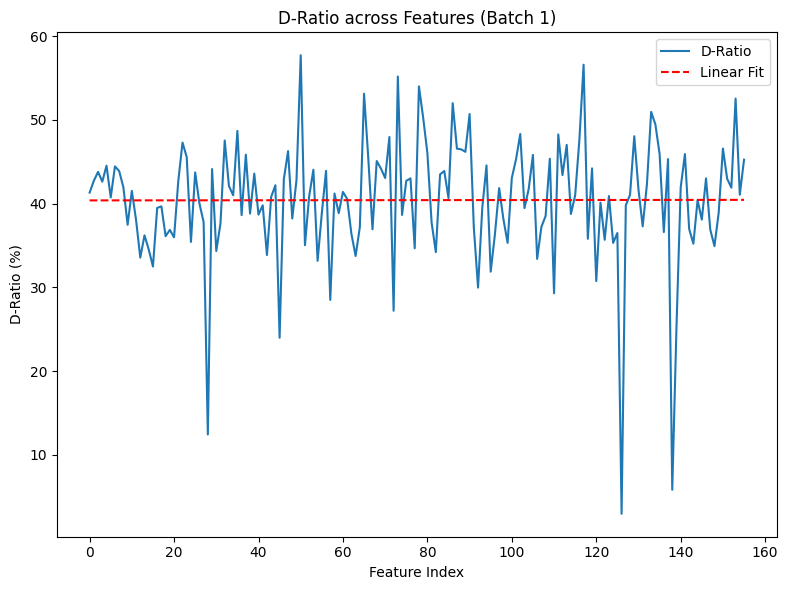

FT-002    41.304044
FT-004    42.724179
FT-005    43.777289
FT-006    42.613427
FT-007    44.518136
            ...    
FT-238    42.968311
FT-240    41.895253
FT-242    52.530455
FT-244    41.053404
FT-248    45.234954
Length: 156, dtype: float64

In [8]:
normalized_data_matrix = median_normalization(filtered_data_matrix, data_matrix_types)
compute_d_ratio(normalized_data_matrix, data_matrix_types, 1)

As expected, the median normalization method was able to reduce the d-ratio from ~60% (on average) to ~40% (on average). This means that batch effects and drifts in instrument sensitivity were significantly removed.

## Feature Selection: variation of intensities

In this section, we will monitor the sample-to-sample intensity variations and check for possible transformations that could improve comparability.

### Intensity Distribution

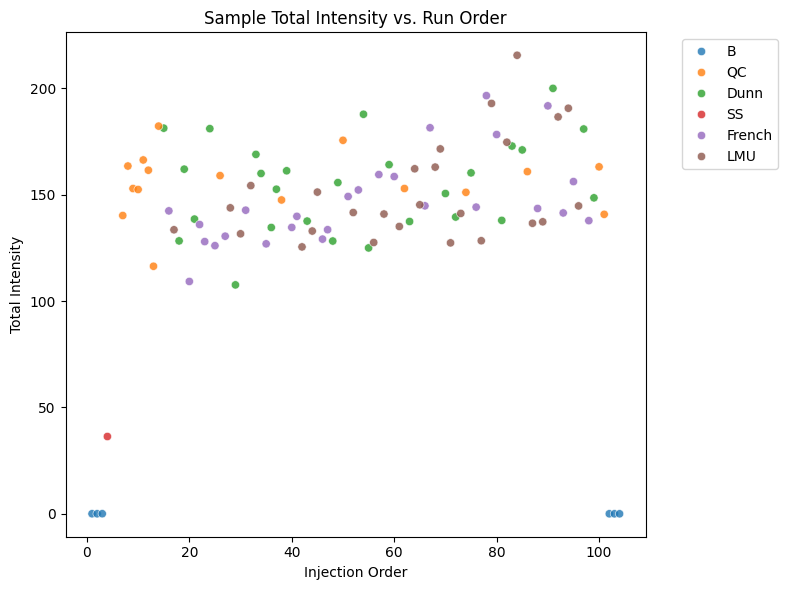

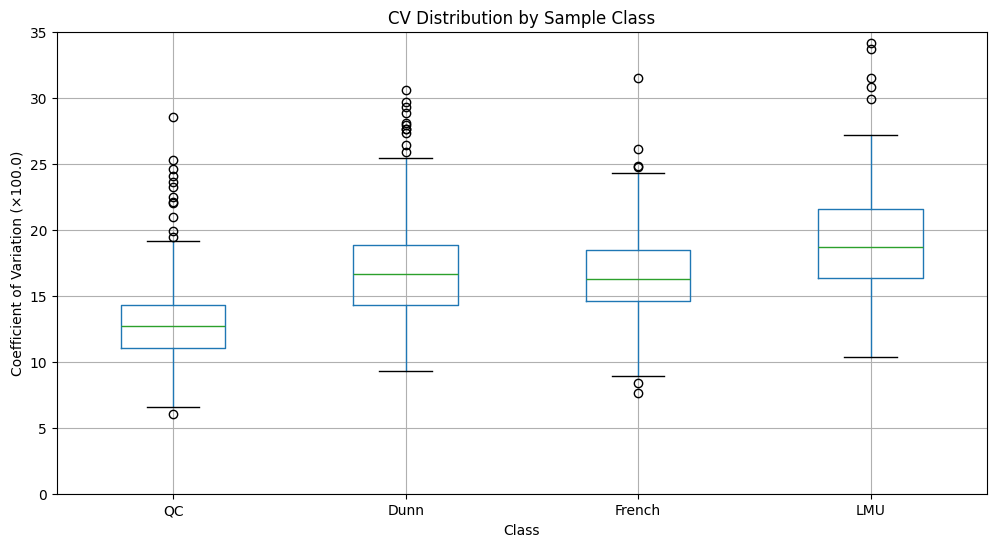

In [9]:
# First, we plot the total intensity vs run order of our normalized filtered data matrix
plot_total_intensity_vs_order(normalized_data_matrix, data_matrix_types)
# We also plot boxplots of CVs across sample classes
plot_cv_boxplots(normalized_data_matrix, data_matrix_types)

- The first plot shows there's notable variation in total intensity across samples.
- The second plot shows that:
    - QC samples have a lower median CV (around 12–13%) which is good.
    - Biological samples show higher median CVs (15–20%) and more spread (some >30%).
    - Outliers go as high as 35% in all classes except QC.

According to the paper [Sources of Technical Variability in Quantitative LC-MS Proteomics: Human Brain Tissue Sample Analysis](https://pmc.ncbi.nlm.nih.gov/articles/PMC3695475/), median CVs are higher than ideal, with significant spread. Some features exceed 30%, suggesting variability that may be technical (e.g., batch effects) rather than biological.

The paper suggests that the best normalization method we can use to mitigate these effects is **global scaling normalization**. Global scaling normalization coefficients are calculated as the ratio of peptide abundance to the median peptide abundance measured across all samples.

Since the intensity distributions of our samples suggest variability, and the CVs are a bit higher than ideal, we will try this method. We then re-check intensity distributions and CVs.

### Normalization Method: Global Scaling Normalization

In [10]:
final_data_matrix = global_scaling_normalization(normalized_data_matrix)

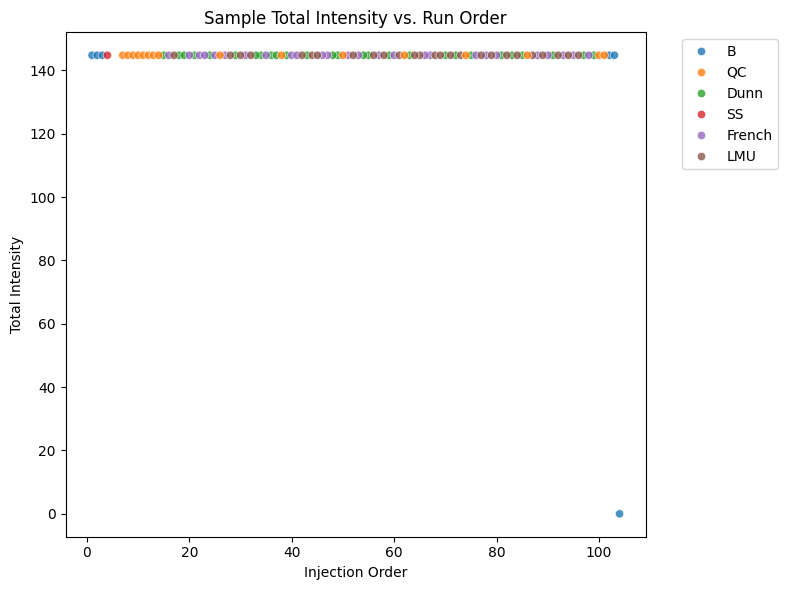

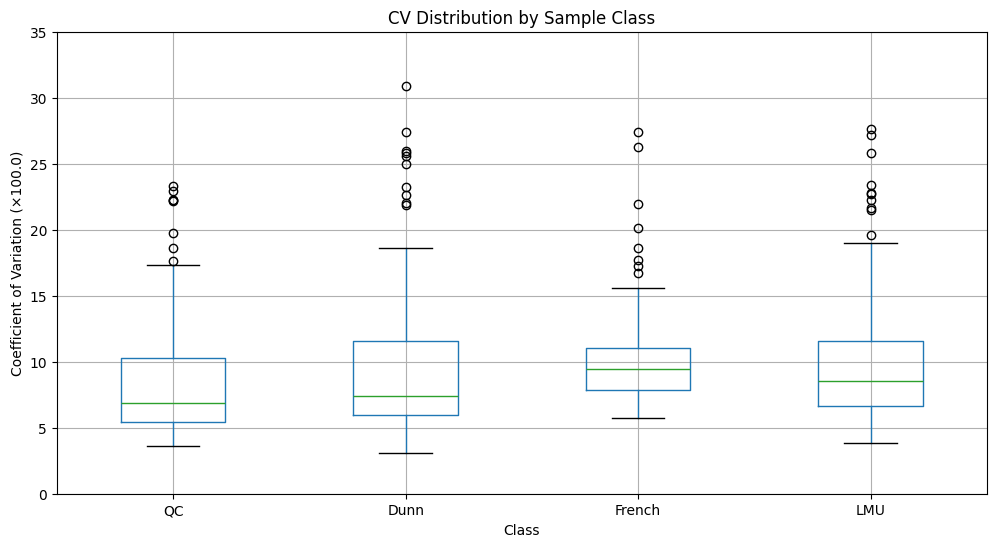

In [11]:
plot_total_intensity_vs_order(final_data_matrix, data_matrix_types)
plot_cv_boxplots(final_data_matrix, data_matrix_types)

- The first plot confirms the normalization was successful: Most samples have uniform total intensity.
- The second plot confirms that after normalization, CVs significantly reduced across all classes. 

## Final Check:

As a final check of the feature selection and transformations we used on our data, we visualize our final filtered data matrix to check whether all selections and transformations were successful.

/Users/aishamasmoudi/Desktop/ml-internship/helpers.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data_matrix[(data_matrix_types['batch'] == batch)]
/Users/aishamasmoudi/Desktop/ml-internship/helpers.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = data[(data_matrix_types['class'] == class_name)]


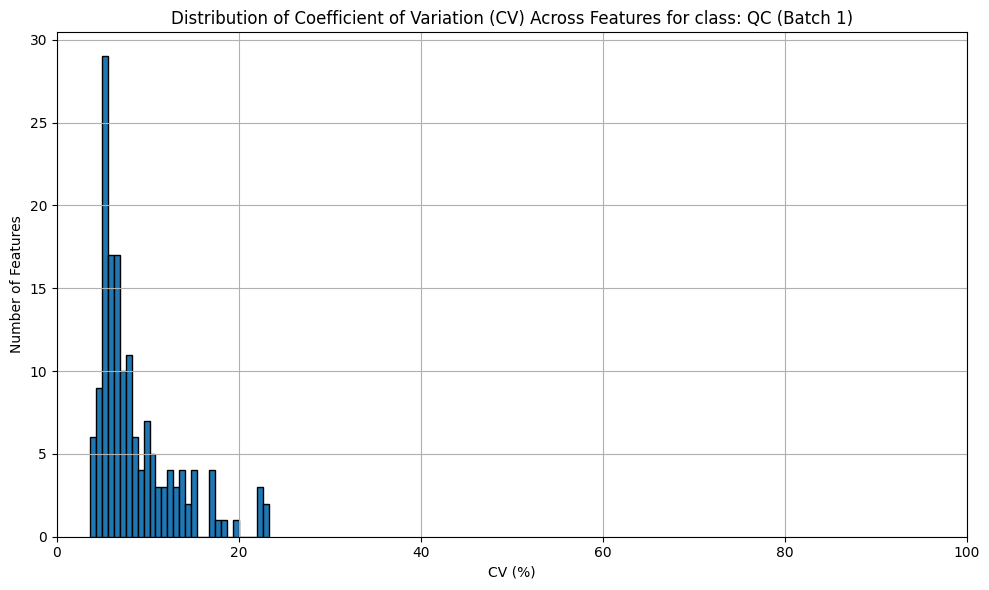

In [12]:
# Compute and Plot CV of features across QC samples
cv_qc = compute_class_cv(final_data_matrix, data_matrix_types, 'QC', 1, visualize=True, xlim=[0, 100])

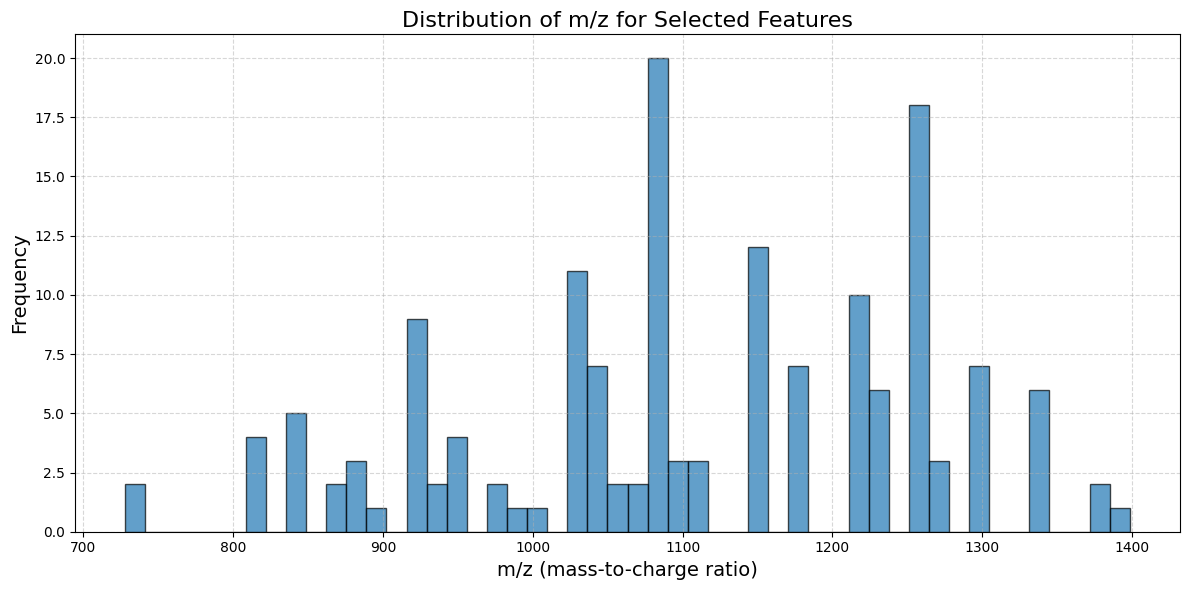

In [13]:
# Plot the distribution of m/z of features
selected_features = feature_metadata.loc[final_data_matrix.columns] # filter feature metadata as to only keep selected features
plt.figure(figsize=(12, 6))
plt.hist(selected_features['mz'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of m/z for Selected Features', fontsize=16)
plt.xlabel('m/z (mass-to-charge ratio)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/Users/aishamasmoudi/Desktop/ml-internship/helpers.py:223: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  numerator = data_matrix[(data_matrix_types['class'] == 'QC') & (data_matrix_types['batch'] == batch)].std()


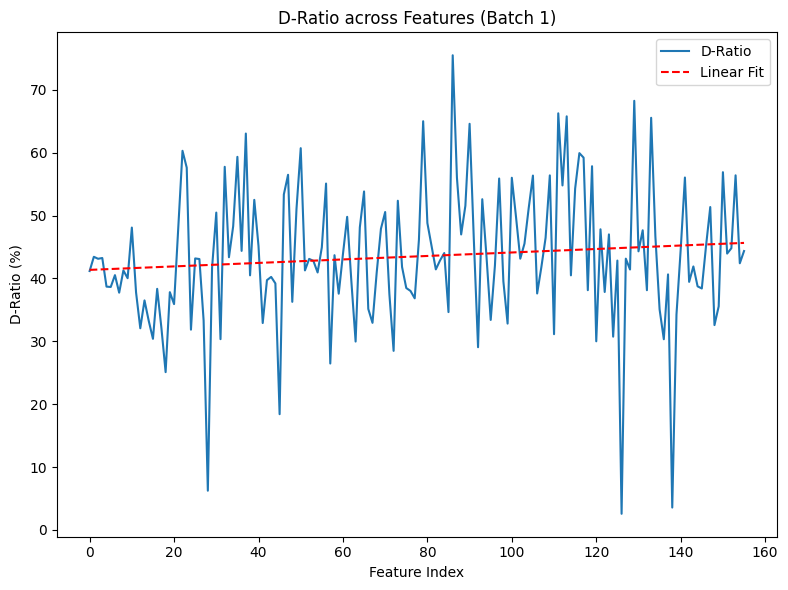

FT-002    41.182726
FT-004    43.447848
FT-005    43.134145
FT-006    43.254874
FT-007    38.705391
            ...    
FT-238    43.961337
FT-240    44.812702
FT-242    56.406660
FT-244    42.418140
FT-248    44.365074
Length: 156, dtype: float64

In [14]:
# Compute the d-ratio
compute_d_ratio(final_data_matrix, data_matrix_types, 1)

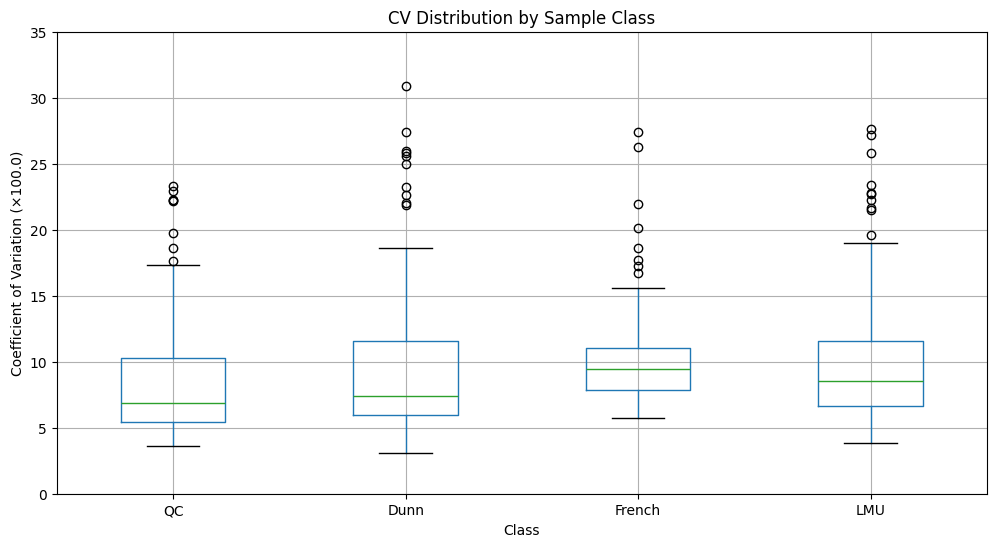

In [15]:
# Plot boxplots of CVs across sample classes
plot_cv_boxplots(final_data_matrix, data_matrix_types)

# Conclusion:
- The distribution of CV across features for QC samples confirms that we only keep features for which the CV is lower than 30%.
- The distribution of m/z confirms that we only keep the features for which m/z is higher than 500, which corresponds to glycans.
- The d-ratio is lower than 50% on average (~40%). 
- CV distribution by samples class shows that the CVs are satisfyingly low.

In [16]:
# Save the final data matrix for biomarker discovery
final_data_matrix = final_data_matrix.dropna()
final_data_matrix.to_csv("./data/input/clean_data_matrix.csv")